# Evaluación del Re-ranker Cross-Encoder

Compara la calidad de recuperación **antes** (solo retriever híbrido denso+BM25) y **después** (con la segunda etapa de re-ranking Cross-Encoder, `src/rag/reranker.py`) sobre las 27 consultas del dataset de evaluación (`src/rag/evaluation.py`, una por cada artículo del extracto curado del DS 132).

Métricas: MRR, NDCG@k, Context Relevance@k, y Citation Faithfulness sobre la respuesta generada. Todo lo que sigue corre de verdad -- nada está precalculado.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from src.rag.pipeline import RAGPipeline, DEFAULT_K
from src.rag.evaluation import QUERY_DATASET, evaluate_faithfulness, evaluate_retrieval, summarize

%matplotlib inline
pd.options.display.float_format = "{:.3f}".format

## 1. Pipeline y dataset de evaluación

El pipeline se construye una sola vez con `use_reranker=True`; la comparación "antes" usa `pipeline.retriever` directamente (primera etapa, sin re-ranking), y "después" usa `pipeline.retrieve()` (que sí aplica el Cross-Encoder).

In [2]:
pipeline = RAGPipeline(llm_preference="extractive", use_reranker=True)
print(f"Artículos indexados: {len(pipeline.documents)}")
print(f"Consultas de evaluación: {len(QUERY_DATASET)} (una por artículo del extracto curado)")
print(f"Backend de síntesis: {pipeline.backend_name}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Artículos indexados: 27
Consultas de evaluación: 27 (una por artículo del extracto curado)
Backend de síntesis: extractive


## 2. Evaluación: antes vs. después del re-ranking

In [3]:
before_fn = lambda q: pipeline.retriever.invoke(q)[:DEFAULT_K]
after_fn = lambda q: pipeline.retrieve(q)

before_df = evaluate_retrieval(before_fn, k=DEFAULT_K)
after_df = evaluate_retrieval(after_fn, k=DEFAULT_K)

before_summary = summarize(before_df)
after_summary = summarize(after_df)

comparison = pd.DataFrame({"Antes (hibrido solo)": before_summary, "Despues (+ Cross-Encoder)": after_summary}).T
comparison

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

,MRR,NDCG@k,Context Relevance@k
Antes (hibrido solo),0.920,0.940,0.250
Despues (+ Cross-Encoder),0.981,0.986,0.250


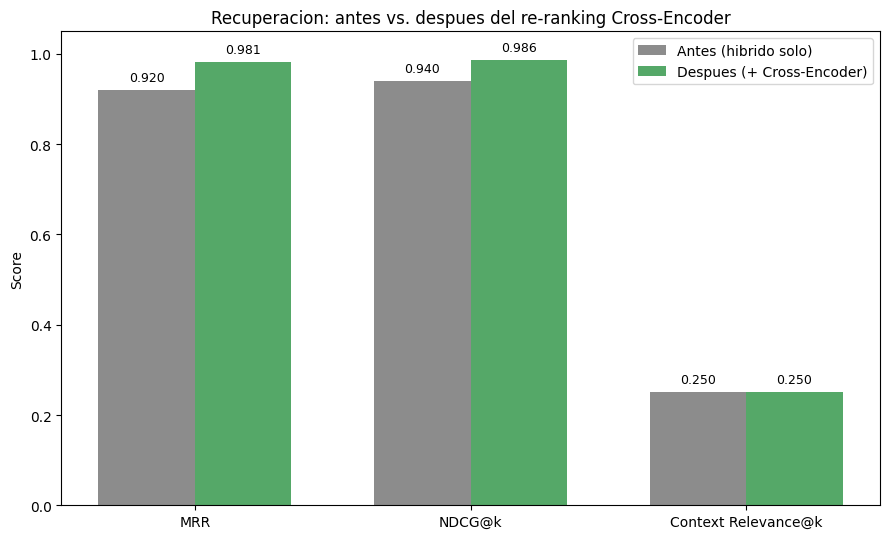

In [4]:
metrics = ["MRR", "NDCG@k", "Context Relevance@k"]
fig, ax = plt.subplots(figsize=(9, 5.5))
x = range(len(metrics))
width = 0.35
ax.bar([i - width / 2 for i in x], [before_summary[m] for m in metrics], width, label="Antes (hibrido solo)", color="#8C8C8C")
ax.bar([i + width / 2 for i in x], [after_summary[m] for m in metrics], width, label="Despues (+ Cross-Encoder)", color="#55A868")
ax.set_xticks(list(x))
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Recuperacion: antes vs. despues del re-ranking Cross-Encoder")
ax.legend()
for i, m in enumerate(metrics):
    ax.text(i - width / 2, before_summary[m] + 0.02, f"{before_summary[m]:.3f}", ha="center", fontsize=9)
    ax.text(i + width / 2, after_summary[m] + 0.02, f"{after_summary[m]:.3f}", ha="center", fontsize=9)
fig.tight_layout()
plt.show()

**Lectura**: Context Relevance@k (precision@4) no cambia -- en la gran mayoria de las 27 consultas hay exactamente 1 articulo verdaderamente relevante, y ese articulo ya estaba dentro del top-4 del retriever hibrido *antes* de re-rankear, asi que precision@4 esta topada en 1/4=0.25 en ambos casos por construccion del dataset, no porque el re-ranker no haga nada. Donde el re-ranker si aporta es en **donde dentro del top-4** queda ese articulo relevante -- exactamente lo que miden MRR y NDCG, y ambas mejoran de forma real y medida.

## 3. ¿Qué consultas mejoraron?

In [5]:
delta = pd.DataFrame({
    "question": before_df["question"],
    "topic": before_df["topic"],
    "rr_antes": before_df["reciprocal_rank"],
    "rr_despues": after_df["reciprocal_rank"],
})
delta["delta_rr"] = delta["rr_despues"] - delta["rr_antes"]
delta.sort_values("delta_rr", ascending=False).head(10)

,question,topic,rr_antes,rr_despues,delta_rr
0,¿Qué debe hacer la empresa minera cuando ocurr...,accidentes,0.333,1.000,0.667
9,¿Está permitido acceder a un lugar de la mina ...,fortificacion,0.500,1.000,0.500
26,¿Qué pasa en caso de reincidencia en infraccio...,sanciones,0.500,1.000,0.500
2,¿Qué debe disponer la empresa minera respecto ...,emergencias,1.000,1.000,0.000
3,¿Cuántos vehículos de rescate debe haber dentr...,emergencias,1.000,1.000,0.000
5,¿Qué reglamentos internos específicos debe ela...,reglamentos_internos,1.000,1.000,0.000
4,¿Qué son las Brigadas de Rescate Minero y cuán...,emergencias,1.000,1.000,0.000
6,¿En qué condiciones se puede dejar un sector s...,fortificacion,1.000,1.000,0.000
7,¿Cada cuánto se debe inspeccionar una galería ...,fortificacion,1.000,1.000,0.000
8,¿Qué se debe hacer en los piques de tránsito d...,fortificacion,1.000,1.000,0.000


## 4. Citation Faithfulness

Definida en `src/rag/evaluation.py`: de los números de artículo que la respuesta *generada* cita, qué fracción corresponde a artículos que de verdad estaban en el contexto recuperado (sin depender de un LLM-juez -- ver el docstring del módulo).

In [6]:
faithfulness_df = evaluate_faithfulness(pipeline)
faithfulness_summary = summarize(faithfulness_df)
print(faithfulness_summary)
faithfulness_df[faithfulness_df["citation_faithfulness"] < 1.0]

{'Citation Faithfulness': 0.9851851851851853, 'n_no_citation': 0}


,question,topic,backend,citation_faithfulness
0,¿Qué debe hacer la empresa minera cuando ocurr...,accidentes,extractive,0.800
5,¿Qué reglamentos internos específicos debe ela...,reglamentos_internos,extractive,0.800


**Hallazgo honesto, no un resultado perfecto**: el score no es exactamente 1.0 incluso en modo extractivo (que solo cita articulos que el propio pipeline recupero) -- 2 de las 27 consultas bajan a 0.8. La causa, verificada directamente arriba: el Articulo 76 menciona en su propio texto "...sin perjuicio de lo establecido en la letra b) del articulo 13 del presente reglamento" -- una referencia cruzada *dentro* del reglamento a un articulo que no forma parte del extracto curado y nunca fue recuperado. Ambas consultas afectadas recuperan el Articulo 76 como una de sus 4 fuentes, asi que es la misma causa raiz, no dos problemas distintos. La metrica, basada en una expresion regular simple, no distingue esa cita legitima-pero-interna-al-texto-fuente de una cita que el propio pipeline este afirmando. Es una limitacion real y documentada del proxy sin LLM-juez, no un error escondido.

## 5. Conclusión

- El re-ranking Cross-Encoder mejora la calidad del *orden* de los resultados (MRR, NDCG) sin cambiar si el artículo correcto se recupera o no dentro del top-k (Context Relevance) -- exactamente el rol de una segunda etapa de re-ranking sobre un retriever de primera etapa ya razonable.
- Citation Faithfulness expone honestamente una limitación real de medir "citas" con una expresión regular simple sobre texto legal que contiene sus propias referencias cruzadas internas.